<a href="https://colab.research.google.com/github/FrosT-27-Patil/Customer-Churn-Code/blob/main/Copy_of_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download("undersc0re/predict-the-churn-risk-rate")

print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'predict-the-churn-risk-rate' dataset.
Dataset downloaded to: /kaggle/input/predict-the-churn-risk-rate


In [38]:
print(os.listdir(path))

['churn.csv']


In [39]:
file_path = os.path.join(path, 'churn.csv')
df = pd.read_csv(file_path)

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nData types of the DataFrame:")
df.info()

First 5 rows of the DataFrame:
   Unnamed: 0  age gender security_no region_category  membership_category  \
0           0   18      F     XW0DQ7H         Village  Platinum Membership   
1           1   32      F     5K0N3X1            City   Premium Membership   
2           2   44      F     1F2TCL3            Town        No Membership   
3           3   37      M     VJGJ33N            City        No Membership   
4           4   31      F     SVZXCWB            City        No Membership   

  joining_date joined_through_referral referral_id     preferred_offer_types  \
0   2017-08-17                      No    xxxxxxxx     Gift Vouchers/Coupons   
1   2017-08-28                       ?    CID21329     Gift Vouchers/Coupons   
2   2016-11-11                     Yes    CID12313     Gift Vouchers/Coupons   
3   2016-10-29                     Yes     CID3793     Gift Vouchers/Coupons   
4   2017-09-12                      No    xxxxxxxx  Credit/Debit Card Offers   

   ... avg_time_spe

In [40]:
#Data Cleaning
df = df.drop('Unnamed: 0', axis=1)
print("DataFrame after dropping 'Unnamed: 0' column:")
print(df.head())

DataFrame after dropping 'Unnamed: 0' column:
   age gender security_no region_category  membership_category joining_date  \
0   18      F     XW0DQ7H         Village  Platinum Membership   2017-08-17   
1   32      F     5K0N3X1            City   Premium Membership   2017-08-28   
2   44      F     1F2TCL3            Town        No Membership   2016-11-11   
3   37      M     VJGJ33N            City        No Membership   2016-10-29   
4   31      F     SVZXCWB            City        No Membership   2017-09-12   

  joined_through_referral referral_id     preferred_offer_types  \
0                      No    xxxxxxxx     Gift Vouchers/Coupons   
1                       ?    CID21329     Gift Vouchers/Coupons   
2                     Yes    CID12313     Gift Vouchers/Coupons   
3                     Yes     CID3793     Gift Vouchers/Coupons   
4                      No    xxxxxxxx  Credit/Debit Card Offers   

  medium_of_operation  ... avg_time_spent avg_transaction_value  \
0        

**Reasoning**:
The next step is to convert the 'avg_frequency_login_days' column to a numeric data type, replacing any non-numeric values like '?' with NaN to ensure proper data type for analysis.



In [41]:
#Converting into numeric values
import numpy as np

df['avg_frequency_login_days'] = df['avg_frequency_login_days'].replace('?', np.nan)
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

print("Data type of 'avg_frequency_login_days' after conversion:")
print(df['avg_frequency_login_days'].dtype)
print("First 5 rows of 'avg_frequency_login_days' column after conversion:")
print(df['avg_frequency_login_days'].head())

Data type of 'avg_frequency_login_days' after conversion:
float64
First 5 rows of 'avg_frequency_login_days' column after conversion:
0    17.0
1    10.0
2    22.0
3     6.0
4    16.0
Name: avg_frequency_login_days, dtype: float64


In [42]:
#converting the 'joining_date' and 'last_visit_time' columns to datetime objects to ensure they are in the correct format for time based analysis
df['joining_date'] = pd.to_datetime(df['joining_date'])
df['last_visit_time'] = pd.to_datetime(df['last_visit_time'])

print("Data types after converting 'joining_date' and 'last_visit_time':")
print(df[['joining_date', 'last_visit_time']].dtypes)
print("First 5 rows of 'joining_date' and 'last_visit_time' columns after conversion:")
print(df[['joining_date', 'last_visit_time']].head())

/tmp/ipykernel_232/2534401234.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_visit_time'] = pd.to_datetime(df['last_visit_time'])


Data types after converting 'joining_date' and 'last_visit_time':
joining_date       datetime64[ns]
last_visit_time    datetime64[ns]
dtype: object
First 5 rows of 'joining_date' and 'last_visit_time' columns after conversion:
  joining_date     last_visit_time
0   2017-08-17 2026-03-09 16:08:02
1   2017-08-28 2026-03-09 12:38:13
2   2016-11-11 2026-03-09 22:53:21
3   2016-10-29 2026-03-09 15:57:50
4   2017-09-12 2026-03-09 15:46:44


In [43]:
df['joining_date'] = pd.to_datetime(df['joining_date'], format='%Y-%m-%d')
df['last_visit_time'] = pd.to_datetime(df['last_visit_time'], format='%Y-%m-%d %H:%M:%S')

print("Data types after converting 'joining_date' and 'last_visit_time':")
print(df[['joining_date', 'last_visit_time']].dtypes)
print("First 5 rows of 'joining_date' and 'last_visit_time' columns after conversion:")
print(df[['joining_date', 'last_visit_time']].head())

Data types after converting 'joining_date' and 'last_visit_time':
joining_date       datetime64[ns]
last_visit_time    datetime64[ns]
dtype: object
First 5 rows of 'joining_date' and 'last_visit_time' columns after conversion:
  joining_date     last_visit_time
0   2017-08-17 2026-03-09 16:08:02
1   2017-08-28 2026-03-09 12:38:13
2   2016-11-11 2026-03-09 22:53:21
3   2016-10-29 2026-03-09 15:57:50
4   2017-09-12 2026-03-09 15:46:44


In [44]:
df['joined_through_referral'] = df['joined_through_referral'].replace('?', np.nan)

print("Unique values in 'joined_through_referral' after replacing '?':")
print(df['joined_through_referral'].unique())

Unique values in 'joined_through_referral' after replacing '?':
['No' nan 'Yes']


In [45]:
region_category_mode = df['region_category'].mode()[0]
preferred_offer_types_mode = df['preferred_offer_types'].mode()[0]

df['region_category'].fillna(region_category_mode, inplace=True)
df['preferred_offer_types'].fillna(preferred_offer_types_mode, inplace=True)

print("Missing values after imputing 'region_category' and 'preferred_offer_types':")
print(df[['region_category', 'preferred_offer_types']].isnull().sum())

Missing values after imputing 'region_category' and 'preferred_offer_types':
region_category          0
preferred_offer_types    0
dtype: int64


/tmp/ipykernel_232/1271038241.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['region_category'].fillna(region_category_mode, inplace=True)
/tmp/ipykernel_232/1271038241.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [46]:
region_category_mode = df['region_category'].mode()[0]
preferred_offer_types_mode = df['preferred_offer_types'].mode()[0]

df['region_category'] = df['region_category'].fillna(region_category_mode)
df['preferred_offer_types'] = df['preferred_offer_types'].fillna(preferred_offer_types_mode)

print("Missing values after imputing 'region_category' and 'preferred_offer_types':")
print(df[['region_category', 'preferred_offer_types']].isnull().sum())

Missing values after imputing 'region_category' and 'preferred_offer_types':
region_category          0
preferred_offer_types    0
dtype: int64


In [47]:
points_in_wallet_mean = df['points_in_wallet'].mean()
df['points_in_wallet'] = df['points_in_wallet'].fillna(points_in_wallet_mean)

print("Missing values after imputing 'points_in_wallet':")
print(df['points_in_wallet'].isnull().sum())

Missing values after imputing 'points_in_wallet':
0


In [48]:
df = df.drop(['security_no', 'referral_id'], axis=1)
print("DataFrame after dropping 'security_no' and 'referral_id' columns:")
print(df.head())

DataFrame after dropping 'security_no' and 'referral_id' columns:
   age gender region_category  membership_category joining_date  \
0   18      F         Village  Platinum Membership   2017-08-17   
1   32      F            City   Premium Membership   2017-08-28   
2   44      F            Town        No Membership   2016-11-11   
3   37      M            City        No Membership   2016-10-29   
4   31      F            City        No Membership   2017-09-12   

  joined_through_referral     preferred_offer_types medium_of_operation  \
0                      No     Gift Vouchers/Coupons                   ?   
1                     NaN     Gift Vouchers/Coupons             Desktop   
2                     Yes     Gift Vouchers/Coupons             Desktop   
3                     Yes     Gift Vouchers/Coupons             Desktop   
4                      No  Credit/Debit Card Offers          Smartphone   

  internet_option     last_visit_time  ...  avg_time_spent  \
0           Wi-Fi 

In [49]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]

print(f"Number of duplicate rows removed: {duplicate_rows_removed}")
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
DataFrame shape after removing duplicates: (36992, 21)


Distribution of churn_risk_score:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64


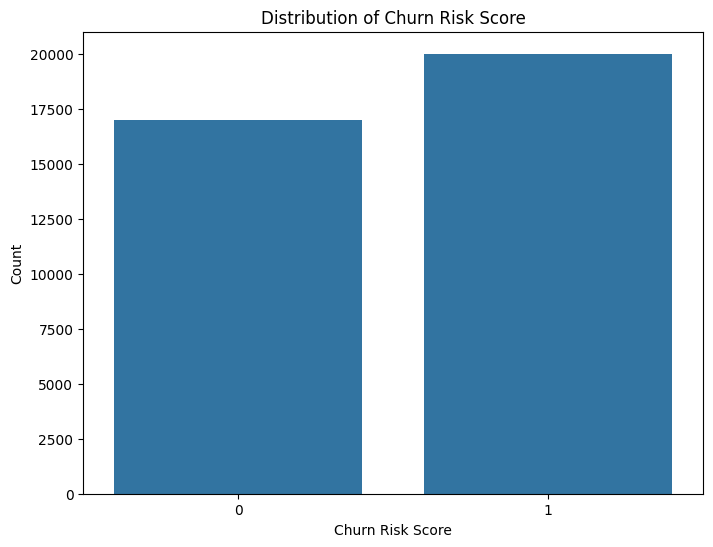

In [50]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of churn_risk_score:")
print(df['churn_risk_score'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='churn_risk_score', data=df)
plt.title('Distribution of Churn Risk Score')
plt.xlabel('Churn Risk Score')
plt.ylabel('Count')
plt.show()

Cross-tabulation of Membership Category and Churn Risk Score:
churn_risk_score        0     1
membership_category            
Basic Membership      251  7473
Gold Membership      4282  2513
No Membership         226  7466
Platinum Membership  4338     0
Premium Membership   4455     0
Silver Membership    3428  2560


<Figure size 1000x700 with 0 Axes>

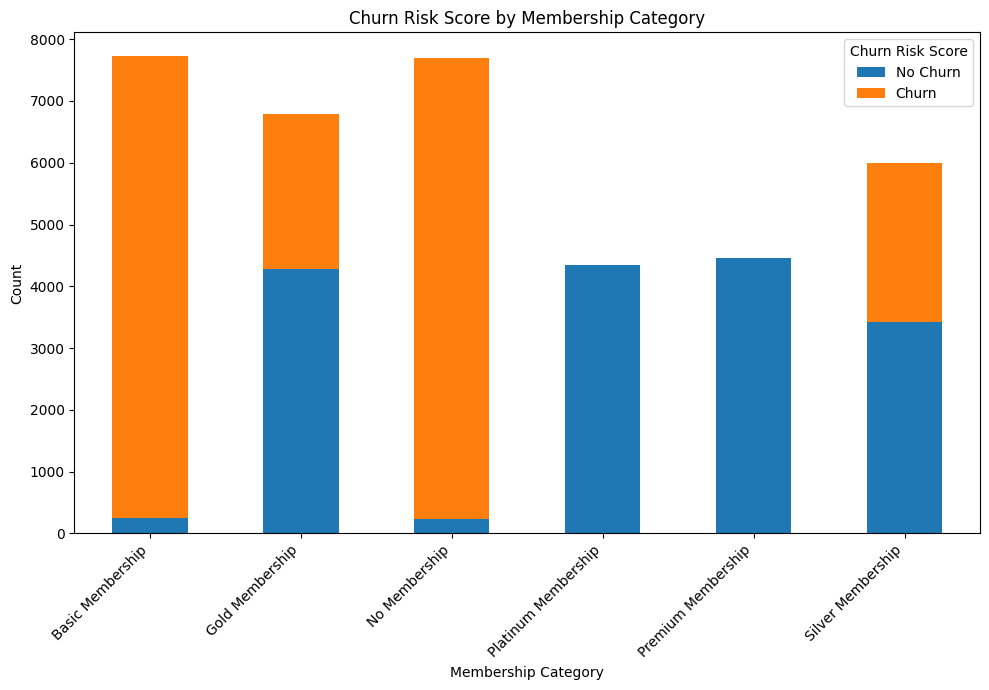

In [51]:
#UNDERSTANDING RELATIONSHIPS
membership_churn_crosstab = pd.crosstab(df['membership_category'], df['churn_risk_score'])
print("Cross-tabulation of Membership Category and Churn Risk Score:")
print(membership_churn_crosstab)

plt.figure(figsize=(10, 7))
membership_churn_crosstab.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Churn Risk Score by Membership Category')
plt.xlabel('Membership Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn Risk Score', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

Correlation Matrix for Numerical Features:
                               age  days_since_last_login  avg_time_spent  \
age                       1.000000              -0.003970        0.001531   
days_since_last_login    -0.003970               1.000000       -0.002369   
avg_time_spent            0.001531              -0.002369        1.000000   
avg_transaction_value    -0.000473               0.003934        0.020888   
avg_frequency_login_days -0.002156               0.000727        0.001820   
points_in_wallet          0.000196               0.008603       -0.000618   
churn_risk_score          0.006124              -0.006228       -0.014263   

                          avg_transaction_value  avg_frequency_login_days  \
age                                   -0.000473                 -0.002156   
days_since_last_login                  0.003934                  0.000727   
avg_time_spent                         0.020888                  0.001820   
avg_transaction_value           

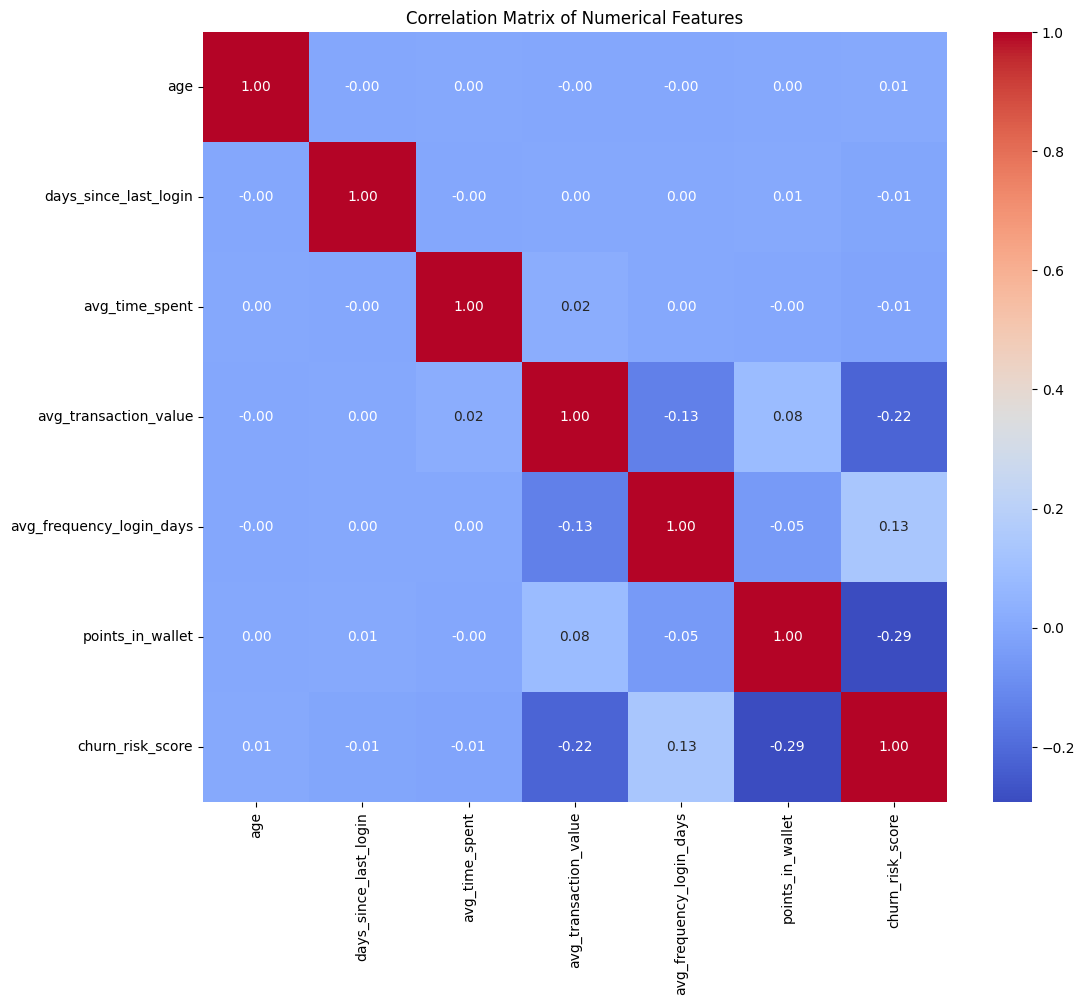

In [52]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix for Numerical Features:")
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [53]:
#FEATURE ENCODING
medium_of_operation_mode = df['medium_of_operation'].replace('?', np.nan).mode()[0]
df['medium_of_operation'] = df['medium_of_operation'].replace('?', medium_of_operation_mode)

print("Unique values in 'medium_of_operation' after replacing '?':")
print(df['medium_of_operation'].unique())

Unique values in 'medium_of_operation' after replacing '?':
['Desktop' 'Smartphone' 'Both']


In [54]:
joined_through_referral_mode = df['joined_through_referral'].mode()[0]
df['joined_through_referral'] = df['joined_through_referral'].fillna(joined_through_referral_mode)

print("Unique values in 'joined_through_referral' after imputation:")
print(df['joined_through_referral'].unique())

Unique values in 'joined_through_referral' after imputation:
['No' 'Yes']


In [55]:
df['customer_lifetime_days'] = (df['last_visit_time'] - df['joining_date']).dt.days

print("First 5 rows with new 'customer_lifetime_days' column:")
print(df[['joining_date', 'last_visit_time', 'customer_lifetime_days']].head())
print("Data type of 'customer_lifetime_days':")
print(df['customer_lifetime_days'].dtype)

First 5 rows with new 'customer_lifetime_days' column:
  joining_date     last_visit_time  customer_lifetime_days
0   2017-08-17 2026-03-09 16:08:02                    3126
1   2017-08-28 2026-03-09 12:38:13                    3115
2   2016-11-11 2026-03-09 22:53:21                    3405
3   2016-10-29 2026-03-09 15:57:50                    3418
4   2017-09-12 2026-03-09 15:46:44                    3100
Data type of 'customer_lifetime_days':
int64


In [56]:
df['joining_year'] = df['joining_date'].dt.year
df['joining_month'] = df['joining_date'].dt.month
df['joining_day'] = df['joining_date'].dt.day
df['joining_dayofweek'] = df['joining_date'].dt.dayofweek

print("New features extracted from 'joining_date' column:")
print(df[['joining_date', 'joining_year', 'joining_month', 'joining_day', 'joining_dayofweek']].head())
print("Data types of new 'joining_date' features:")
print(df[['joining_year', 'joining_month', 'joining_day', 'joining_dayofweek']].dtypes)

New features extracted from 'joining_date' column:
  joining_date  joining_year  joining_month  joining_day  joining_dayofweek
0   2017-08-17          2017              8           17                  3
1   2017-08-28          2017              8           28                  0
2   2016-11-11          2016             11           11                  4
3   2016-10-29          2016             10           29                  5
4   2017-09-12          2017              9           12                  1
Data types of new 'joining_date' features:
joining_year         int32
joining_month        int32
joining_day          int32
joining_dayofweek    int32
dtype: object


In [57]:
df['last_visit_hour'] = df['last_visit_time'].dt.hour
df['last_visit_minute'] = df['last_visit_time'].dt.minute

print("New features extracted from 'last_visit_time' column:")
print(df[['last_visit_time', 'last_visit_hour', 'last_visit_minute']].head())
print("Data types of new 'last_visit_time' features:")
print(df[['last_visit_hour', 'last_visit_minute']].dtypes)

New features extracted from 'last_visit_time' column:
      last_visit_time  last_visit_hour  last_visit_minute
0 2026-03-09 16:08:02               16                  8
1 2026-03-09 12:38:13               12                 38
2 2026-03-09 22:53:21               22                 53
3 2026-03-09 15:57:50               15                 57
4 2026-03-09 15:46:44               15                 46
Data types of new 'last_visit_time' features:
last_visit_hour      int32
last_visit_minute    int32
dtype: object


In [58]:
df = df.drop(['joining_date', 'last_visit_time'], axis=1)

print("DataFrame after dropping 'joining_date' and 'last_visit_time' columns:")
print(df.head())

DataFrame after dropping 'joining_date' and 'last_visit_time' columns:
   age gender region_category  membership_category joined_through_referral  \
0   18      F         Village  Platinum Membership                      No   
1   32      F            City   Premium Membership                      No   
2   44      F            Town        No Membership                     Yes   
3   37      M            City        No Membership                     Yes   
4   31      F            City        No Membership                      No   

      preferred_offer_types medium_of_operation internet_option  \
0     Gift Vouchers/Coupons             Desktop           Wi-Fi   
1     Gift Vouchers/Coupons             Desktop     Mobile_Data   
2     Gift Vouchers/Coupons             Desktop           Wi-Fi   
3     Gift Vouchers/Coupons             Desktop     Mobile_Data   
4  Credit/Debit Card Offers          Smartphone     Mobile_Data   

   days_since_last_login  avg_time_spent  ...     complai

In [59]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
binary_cols = []
multiclass_cols = []

for col in categorical_cols:
    if df[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multiclass_cols.append(col)

print(f"Binary Categorical Columns: {binary_cols}")
print(f"Multi-class Categorical Columns: {multiclass_cols}")

Binary Categorical Columns: ['joined_through_referral', 'used_special_discount', 'offer_application_preference', 'past_complaint']
Multi-class Categorical Columns: ['gender', 'region_category', 'membership_category', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'complaint_status', 'feedback']


In [60]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("First 5 rows of DataFrame after Label Encoding binary columns:")
print(df[binary_cols].head())
print("\nData types of binary columns after Label Encoding:")
print(df[binary_cols].dtypes)

First 5 rows of DataFrame after Label Encoding binary columns:
   joined_through_referral  used_special_discount  \
0                        0                      1   
1                        0                      1   
2                        1                      0   
3                        1                      0   
4                        0                      0   

   offer_application_preference  past_complaint  
0                             1               0  
1                             0               1  
2                             1               1  
3                             1               1  
4                             1               1  

Data types of binary columns after Label Encoding:
joined_through_referral         int64
used_special_discount           int64
offer_application_preference    int64
past_complaint                  int64
dtype: object


In [61]:
#ONE HOT ENCODING
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True, dtype=int)

print("First 5 rows of DataFrame after One-Hot Encoding multi-class columns:")
print(df.head())
print("\nData types of some newly created One-Hot Encoded columns:")
print(df.filter(like='_').dtypes.head())

First 5 rows of DataFrame after One-Hot Encoding multi-class columns:
   age  joined_through_referral  days_since_last_login  avg_time_spent  \
0   18                        0                     17          300.63   
1   32                        0                     16          306.34   
2   44                        1                     14          516.16   
3   37                        1                     11           53.27   
4   31                        0                     20          113.13   

   avg_transaction_value  avg_frequency_login_days  points_in_wallet  \
0               53005.25                      17.0        781.750000   
1               12838.38                      10.0        686.882199   
2               21027.00                      22.0        500.690000   
3               25239.56                       6.0        567.660000   
4               24483.66                      16.0        663.060000   

   used_special_discount  offer_application_preferen

In [62]:
#TRAIN TEST SPILT
X = df.drop('churn_risk_score', axis=1)
y = df['churn_risk_score']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (36992, 44)
Shape of y (target): (36992,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (29593, 44)
Shape of X_test: (7399, 44)
Shape of y_train: (29593,)
Shape of y_test: (7399,)


In [64]:
#FEATURE SCALING
numerical_features_to_scale = [
    'age',
    'days_since_last_login',
    'avg_time_spent',
    'avg_transaction_value',
    'avg_frequency_login_days',
    'points_in_wallet',
    'customer_lifetime_days',
    'joining_year',
    'joining_month',
    'joining_day',
    'joining_dayofweek',
    'last_visit_hour',
    'last_visit_minute'
]

print("Numerical features identified for scaling:")
print(numerical_features_to_scale)

Numerical features identified for scaling:
['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'customer_lifetime_days', 'joining_year', 'joining_month', 'joining_day', 'joining_dayofweek', 'last_visit_hour', 'last_visit_minute']


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print("First 5 rows of X_train after scaling numerical features:")
print(X_train[numerical_features_to_scale].head())
print("\nFirst 5 rows of X_test after scaling numerical features:")
print(X_test[numerical_features_to_scale].head())

First 5 rows of X_train after scaling numerical features:
            age  days_since_last_login  avg_time_spent  avg_transaction_value  \
4278  -0.260639               0.256902       -0.383440              -0.985435   
33543 -1.582957               0.239383        0.486295               2.877227   
22645 -1.519989              -4.192690       -1.985860              -0.869792   
23084 -1.394054               0.270040        0.396424               3.199536   
21758 -0.386574               0.239383        1.648911               1.434695   

       avg_frequency_login_days  points_in_wallet  customer_lifetime_days  \
4278                        NaN          0.503045               -1.716794   
33543                 -1.513669         -0.958680               -0.220261   
22645                 -0.862287          0.366286               -0.922844   
23084                 -0.536596          0.002023               -1.007910   
21758                 -0.862287          0.294024               -0.648

In [66]:
#MODEL TRAINING
avg_frequency_login_days_mean = X_train['avg_frequency_login_days'].mean()
X_train['avg_frequency_login_days'].fillna(avg_frequency_login_days_mean, inplace=True)
X_test['avg_frequency_login_days'].fillna(avg_frequency_login_days_mean, inplace=True)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Train Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
print("Logistic Regression Model trained.")

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Model trained.")

# Train Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model trained.")

/tmp/ipykernel_232/3211062908.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['avg_frequency_login_days'].fillna(avg_frequency_login_days_mean, inplace=True)
/tmp/ipykernel_232/3211062908.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

Logistic Regression Model trained.
Decision Tree Model trained.
Random Forest Model trained.


In [67]:
avg_frequency_login_days_mean = X_train['avg_frequency_login_days'].mean()
X_train['avg_frequency_login_days'] = X_train['avg_frequency_login_days'].fillna(avg_frequency_login_days_mean)
X_test['avg_frequency_login_days'] = X_test['avg_frequency_login_days'].fillna(avg_frequency_login_days_mean)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Train Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
print("Logistic Regression Model trained.")

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Model trained.")

# Train Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model trained.")

Logistic Regression Model trained.
Decision Tree Model trained.
Random Forest Model trained.


In [68]:
#Model Evaluation and comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Classification metrics imported successfully.")

Classification metrics imported successfully.


In [69]:
model_performance = {}

# Evaluate Logistic Regression Model
y_pred_log_reg = log_reg_model.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average='weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average='weighted')
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='weighted')

model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_log_reg,
    'Precision': precision_log_reg,
    'Recall': recall_log_reg,
    'F1-Score': f1_log_reg
}
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log_reg))

# Evaluate Decision Tree Model
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

model_performance['Decision Tree'] = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt
}
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# Evaluate Random Forest Model
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

model_performance['Random Forest'] = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf
}
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

print("\nModel Performance Summary:")
for model, metrics in model_performance.items():
    print(f"\n{model}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      3396
           1       0.92      0.89      0.90      4003

    accuracy                           0.90      7399
   macro avg       0.90      0.90      0.90      7399
weighted avg       0.90      0.90      0.90      7399


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3396
           1       0.92      0.91      0.91      4003

    accuracy                           0.91      7399
   macro avg       0.91      0.91      0.91      7399
weighted avg       0.91      0.91      0.91      7399


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3396
           1       0.92      0.95      0.94      4003

    accuracy                           0.

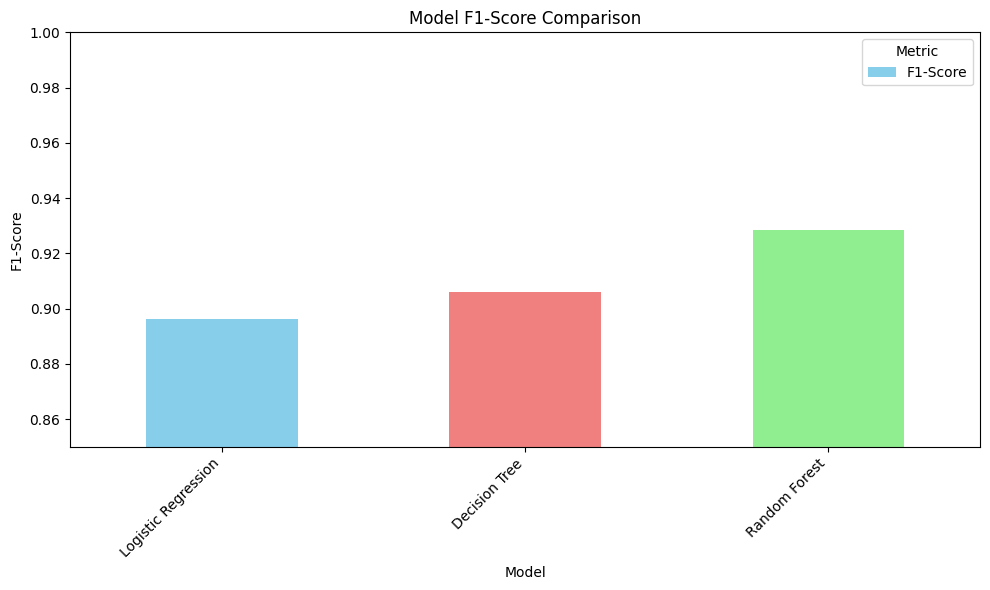

In [70]:
model_performance_df = pd.DataFrame(model_performance).T

plt.figure(figsize=(10, 6))
model_performance_df['F1-Score'].plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0.85, 1.0) # Set y-axis limits for better visualization of differences
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', labels=['F1-Score'])
plt.tight_layout()
plt.show()

In [71]:
#prediction
y_pred_rf = rf_model.predict(X_test)

print("First 10 predicted churn risk scores (Random Forest):")
print(y_pred_rf[:10])
print("\nFirst 10 actual churn risk scores:")
print(y_test.head(10))

print("\nValue counts of predicted churn risk scores (Random Forest):")
print(pd.Series(y_pred_rf).value_counts())

First 10 predicted churn risk scores (Random Forest):
[0 1 0 1 0 1 0 0 1 1]

First 10 actual churn risk scores:
2196     0
29470    1
6845     0
21613    1
29472    0
17645    1
12223    0
15479    1
25664    1
30119    1
Name: churn_risk_score, dtype: int64

Value counts of predicted churn risk scores (Random Forest):
1    4135
0    3264
Name: count, dtype: int64
